In [ ]:
# imports
import numpy as np
import scipy.linalg as slin

from dual_pfc_funcs import getParams, gen_GP

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')
SAVE_FIG = False

# params
color_map = getParams()['color_map']
num_neurons = 20
num_timepoints = 1000
GP_tau = 50
base_p = 1e-2
c = 5
base_add = 0.05

/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_67397/4165558503.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


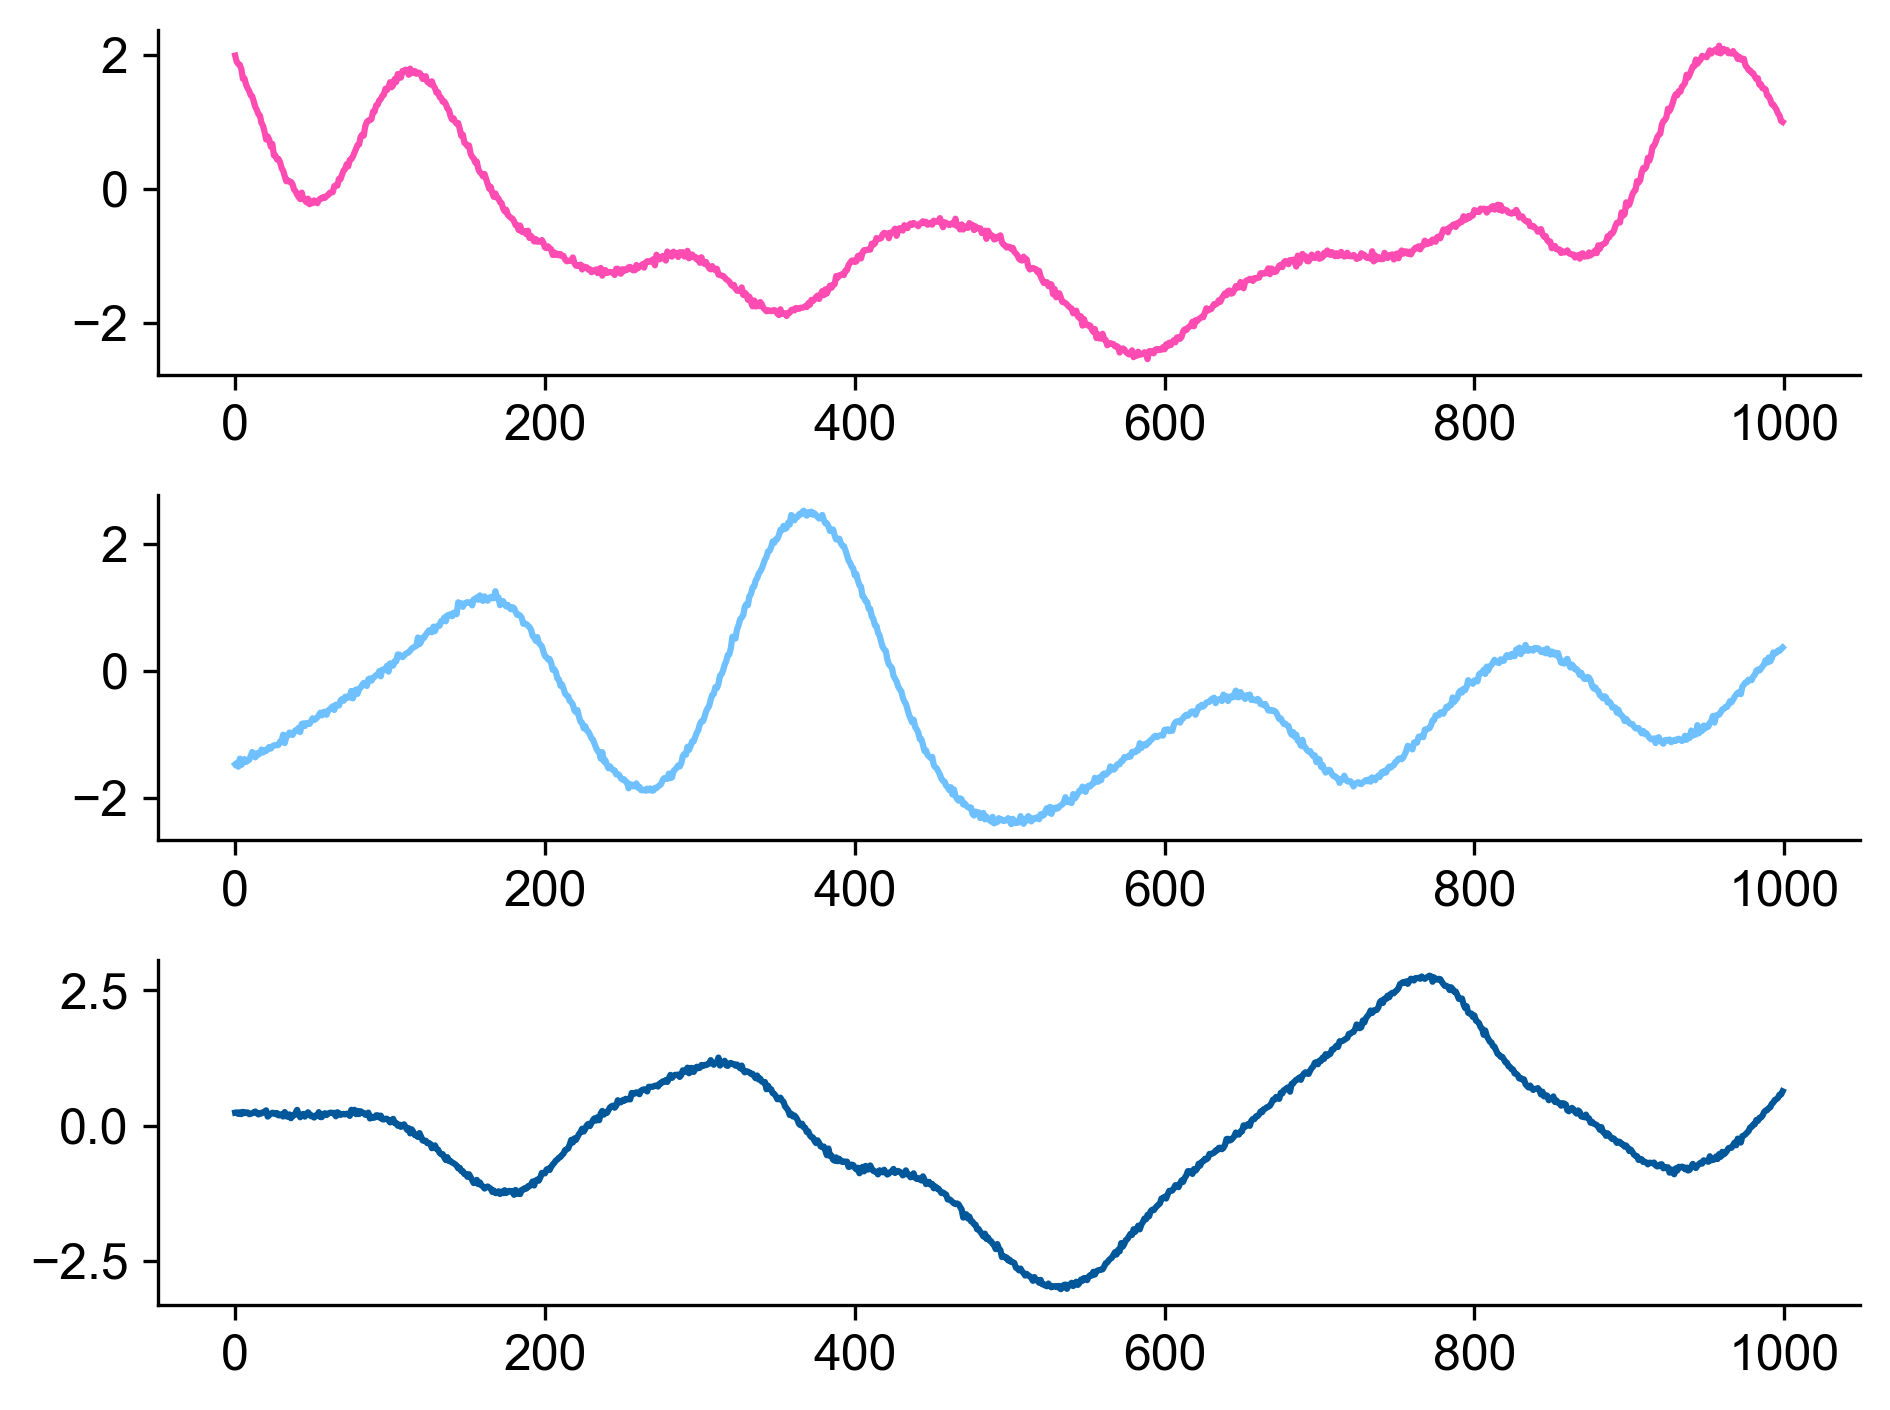

In [3]:
# create figure to plot generated latents
fig,ax = plt.subplots(3,1,tight_layout=True)

# generate global latent
across_z = gen_GP(GP_tau, num_timepoints, seed=0)
ax[0].plot(across_z,color=color_map['across'])

# generate local left latent
within_z = gen_GP(GP_tau, num_timepoints, seed=2, N=2)
left_z = within_z[:,0]
ax[1].plot(left_z,color=color_map['within1'])

# generate local right latent
right_z = within_z[:,1]
ax[2].plot(right_z,color=color_map['within2'])

if SAVE_FIG:
    pdf = PdfPages('figs/rsc_example_sess.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

In [4]:
# generate across-area loadings
np.random.seed(0)
glb_L = np.random.randn(num_neurons) + 1
glb_L /= slin.norm(glb_L)

# generate left loadings
np.random.seed(1)
left_L = np.random.randn(num_neurons) + 1
left_L /= slin.norm(left_L)

# generate right loadings
np.random.seed(6)
right_L = np.random.randn(num_neurons) + 1
right_L /= slin.norm(right_L)

# generate spike trains
left_raster = np.zeros((num_neurons,num_timepoints))
right_raster = np.zeros((num_neurons,num_timepoints))

for ineuron in range(num_neurons):
    # left
    zi = glb_L[ineuron]*across_z + left_L[ineuron]*left_z
    if np.max(zi) <= 0:
        zi[zi <= 0] = base_p
    else:
        zi = zi / np.max(zi) / c # control overall firing by d
        zi = zi + base_add
    zi[zi <= 0] = base_p
    left_raster[ineuron,:] = np.random.binomial(np.ones((num_timepoints,)).astype('int'), zi)
    
    # right
    zi = glb_L[ineuron]*across_z + right_L[ineuron]*right_z
    if np.max(zi) <= 0:
        zi[zi <= 0] = base_p
    else:
        zi = zi / np.max(zi) / c # control overall firing by d
        zi = zi + base_add
    zi[zi <= 0] = base_p
    right_raster[ineuron,:] = np.random.binomial(np.ones((num_timepoints,)).astype('int'), zi)

/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_67397/3050469297.py:24: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


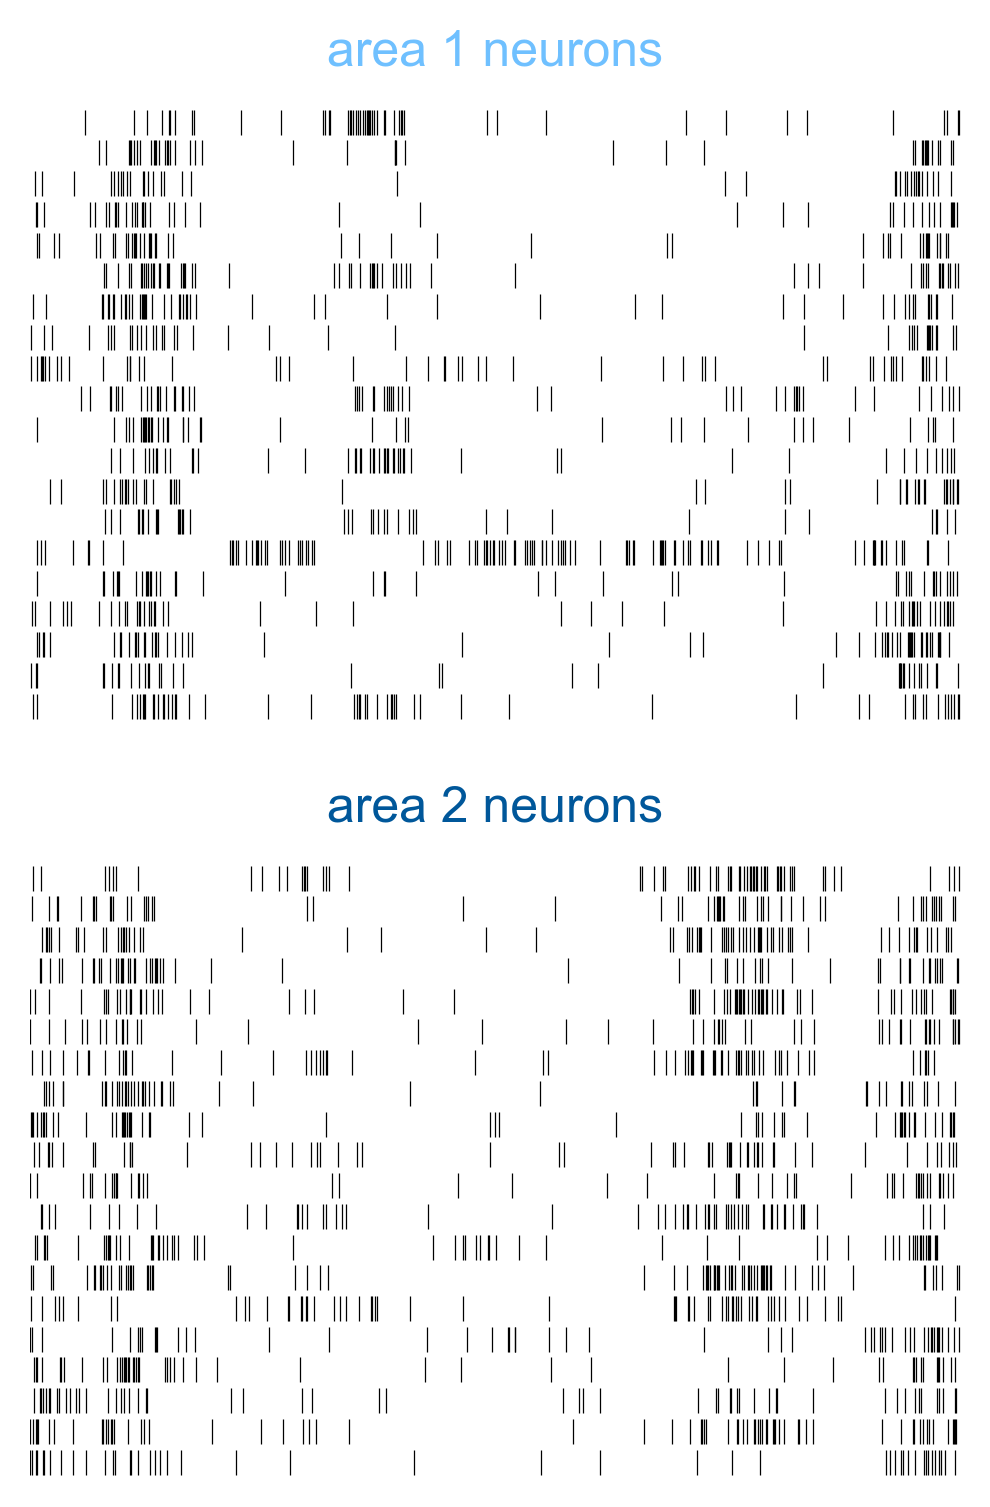

In [5]:
# plot rasters
fig,ax = plt.subplots(2,1,figsize=(4,6),sharex=True,sharey=True)

ax[0].scatter(np.where(left_raster)[1],np.where(left_raster)[0],marker='|',color='k',linewidth=0.3)
ax[1].scatter(np.where(right_raster)[1],np.where(right_raster)[0],marker='|',color='k',linewidth=0.3)

ax[0].set_title('area 1 neurons',color=color_map['within1'])
ax[0].set_xlim([0,1000])
ax[0].set_ylim([-0.5,num_neurons])
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].spines[['left','bottom']].set_visible(False)

ax[1].set_title('area 2 neurons',color=color_map['within2'])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].spines[['left','bottom']].set_visible(False)

if SAVE_FIG:
    pdf = PdfPages('figs/sim_rasters.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()